In [1]:
import pandas as pd
import numpy as np
import os
import joblib
import datetime

from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    precision_recall_curve,
    auc,
    classification_report,
    confusion_matrix,
    matthews_corrcoef
)

import matplotlib.pyplot as plt

In [2]:
dir = r"try_02"

# Original (unscaled) splits — used by RF
x_train = pd.read_pickle(os.path.join(dir, "x_train.pkl"))
x_test  = pd.read_pickle(os.path.join(dir, "x_test.pkl"))

y_train = pd.read_pickle(os.path.join(dir, "y_train.pkl"))
y_test  = pd.read_pickle(os.path.join(dir, "y_test.pkl"))

# Scaled splits — used by MLP
x_train_scaled = pd.read_pickle(os.path.join(dir, "x_train_scaled.pkl"))
x_test_scaled  = pd.read_pickle(os.path.join(dir, "x_test_scaled.pkl"))

# Random Forest models
rf1 = joblib.load(os.path.join(dir, "model_maxdepthNone.pkl"))
rf2 = joblib.load(os.path.join(dir, "model_maxdepth10.pkl"))

# MLP models
mlp1 = joblib.load(os.path.join(dir, "model_mlp_shallow.pkl"))
mlp2 = joblib.load(os.path.join(dir, "model_mlp_deep.pkl"))

print("All models and data loaded.")

c:\Anaconda\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Anaconda\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


All models and data loaded.


## Helper Functions

In [3]:
def compute_pr_curve(model, x, y_test):
    y_prob = model.predict_proba(x)[:, 1]

    precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
    pr_auc = auc(recall, precision)

    return y_prob, precision, recall, thresholds, pr_auc

In [4]:
def find_best_threshold(precision, recall, thresholds, y_prob, max_fraud_rate=0.25):
    f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-8)

    # Mask out thresholds that predict more than max_fraud_rate as fraud
    predicted_fraud_rates = np.array([(y_prob >= t).mean() for t in thresholds])
    valid = predicted_fraud_rates <= max_fraud_rate

    if valid.any():
        best_idx = np.argmax(f1_scores * valid)
    else:
        best_idx = np.argmax(f1_scores)
        print("Warning: all thresholds exceed max_fraud_rate cap, using uncapped best")

    best_threshold = thresholds[best_idx]
    print(f"Best Threshold              : {best_threshold:.4f}")
    print(f"Best F1                     : {f1_scores[best_idx]:.4f}")
    print(f"Predicted fraud rate        : {predicted_fraud_rates[best_idx]:.4f}")

    return best_threshold, f1_scores

In [5]:
def evaluate_thresholds(y_prob, y_test, thresholds_list=[0.1, 0.2, 0.3, 0.4, 0.5]):
    for t in thresholds_list:
        print(f"\n===== Threshold: {t} =====")

        y_pred = (y_prob >= t).astype(int)

        print("Confusion Matrix:")
        print(confusion_matrix(y_test, y_pred))

        print("\nClassification Report:")
        print(classification_report(y_test, y_pred))

In [6]:
def final_evaluation(y_prob, y_test, threshold):
    print("\n===== FINAL MODEL EVALUATION =====")
    print("\nBest Threshold:", threshold)

    y_pred = (y_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    mcc         = matthews_corrcoef(y_test, y_pred)

    print("\n--- Overall Metrics ---")
    print(f"Accuracy    : {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision   : {precision_score(y_test, y_pred):.4f}")
    print(f"Recall      : {recall_score(y_test, y_pred):.4f}")
    print(f"Specificity : {specificity:.4f}")
    print(f"F1 Score    : {f1_score(y_test, y_pred):.4f}")
    print(f"MCC         : {mcc:.4f}")
    print(f"PR-AUC      : {average_precision_score(y_test, y_prob):.4f}")

    print("\n--- Confusion Matrix ---")
    print(confusion_matrix(y_test, y_pred))

    print("\n--- Classification Report ---")
    print(classification_report(y_test, y_pred))

In [7]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(y_true, y_prob, threshold, title="Confusion Matrix"):
    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    
    labels = ["Not Fraud (0)", "Fraud (1)"]
    
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt=",d",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels,
        ax=ax
    )
    ax.set_xlabel("Predicted Label", fontsize=12)
    ax.set_ylabel("True Label", fontsize=12)
    ax.set_title(title, fontsize=14)
    plt.tight_layout()
    plt.show()

## Precision-Recall Curve — All Models

RF models use unscaled data; MLP models use scaled data.

c:\Anaconda\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but MLPClassifier was fitted without feature names
  warnings.warn(
c:\Anaconda\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but MLPClassifier was fitted without feature names
  warnings.warn(


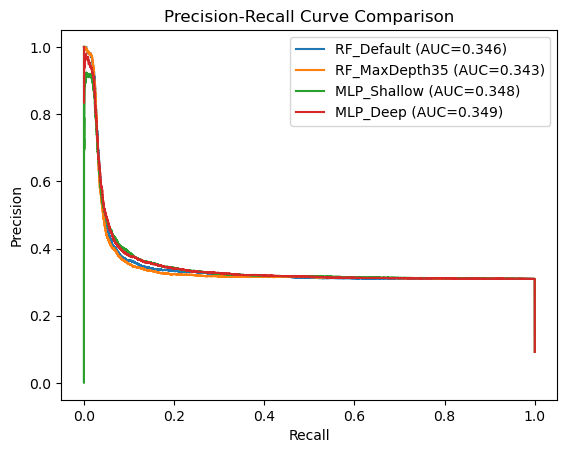

In [8]:
# Build a unified models dict: (model, x_input)
models = {
    "RF_Default":    (rf1,  x_test),
    "RF_MaxDepth35": (rf2,  x_test),
    "MLP_Shallow":   (mlp1, x_test_scaled),
    "MLP_Deep":      (mlp2, x_test_scaled),
}

plt.figure()
for name, (model, x) in models.items():
    y_prob = model.predict_proba(x)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, label=f"{name} (AUC={pr_auc:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend()
plt.show()

## Random Forest Models

In [9]:
y_prob1, precision1, recall1, thresholds1, pr_auc1 = compute_pr_curve(rf1, x_test, y_test)
best_threshold1, _ = find_best_threshold(precision1, recall1, thresholds1, y_prob1)
print("\n")
y_prob2, precision2, recall2, thresholds2, pr_auc2 = compute_pr_curve(rf2, x_test, y_test)
best_threshold2, _ = find_best_threshold(precision2, recall2, thresholds2, y_prob2)

Best Threshold              : 0.4357
Best F1                     : 0.4532
Predicted fraud rate        : 0.2499


Best Threshold              : 0.6518
Best F1                     : 0.4530
Predicted fraud rate        : 0.2499


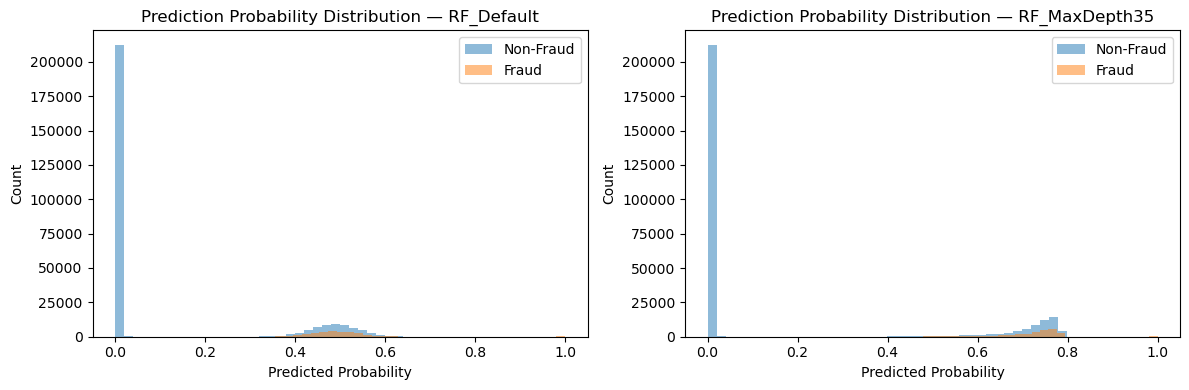

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, y_prob, title in zip(axes, [y_prob1, y_prob2], ["RF_Default", "RF_MaxDepth35"]):
    ax.hist(y_prob[y_test == 0], bins=50, alpha=0.5, label="Non-Fraud")
    ax.hist(y_prob[y_test == 1], bins=50, alpha=0.5, label="Fraud")
    ax.legend()
    ax.set_title(f"Prediction Probability Distribution — {title}")
    ax.set_xlabel("Predicted Probability")
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

In [11]:
# evaluate_thresholds(y_prob1, y_test)
# evaluate_thresholds(y_prob2, y_test)

In [12]:
final_evaluation(y_prob1, y_test, best_threshold1)


===== FINAL MODEL EVALUATION =====

Best Threshold: 0.4356884338089838

--- Overall Metrics ---
Accuracy    : 0.8129
Precision   : 0.3102
Recall      : 0.8409
Specificity : 0.8101
F1 Score    : 0.4532
MCC         : 0.4350
PR-AUC      : 0.3459

--- Confusion Matrix ---
[[222865  52255]
 [  4444  23494]]

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.98      0.81      0.89    275120
           1       0.31      0.84      0.45     27938

    accuracy                           0.81    303058
   macro avg       0.65      0.83      0.67    303058
weighted avg       0.92      0.81      0.85    303058



In [13]:
final_evaluation(y_prob2, y_test, best_threshold2)


===== FINAL MODEL EVALUATION =====

Best Threshold: 0.6518219260519952

--- Overall Metrics ---
Accuracy    : 0.8129
Precision   : 0.3101
Recall      : 0.8406
Specificity : 0.8101
F1 Score    : 0.4530
MCC         : 0.4347
PR-AUC      : 0.3428

--- Confusion Matrix ---
[[222864  52256]
 [  4454  23484]]

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.98      0.81      0.89    275120
           1       0.31      0.84      0.45     27938

    accuracy                           0.81    303058
   macro avg       0.65      0.83      0.67    303058
weighted avg       0.92      0.81      0.85    303058



In [14]:
feature_importance = pd.DataFrame({
    "features": x_train.columns,
    "importance": rf1.feature_importances_
}).sort_values(by="importance", ascending=False)

feature_importance.head(32)

,features,importance
8,transactionType_TRANSFER,0.176648
28,RECIP_RISK_24,0.116327
0,amount,0.086788
26,RECIP_RISK_12,0.082850
24,RECIP_RISK_6,0.057038
11,balance_increase_ratio,0.040666
7,transactionType_PAYMENT,0.036094
10,amount_balance_ratio,0.033018
16,INIT_AMOUNT_DEV_TX_6,0.032969
14,balance_error_r,0.029067


In [15]:
feature_importance = pd.DataFrame({
    "features": x_train.columns,
    "importance": rf2.feature_importances_
}).sort_values(by="importance", ascending=False)

feature_importance.head(32)

,features,importance
8,transactionType_TRANSFER,0.221545
28,RECIP_RISK_24,0.139545
0,amount,0.101112
26,RECIP_RISK_12,0.094026
24,RECIP_RISK_6,0.066768
7,transactionType_PAYMENT,0.043448
11,balance_increase_ratio,0.035692
14,balance_error_r,0.028099
6,transactionType_DEPOSIT,0.027770
13,balance_error_i,0.026322


## MLP Models

In [16]:
y_prob_mlp1, precision_mlp1, recall_mlp1, thresholds_mlp1, pr_auc_mlp1 = compute_pr_curve(mlp1, x_test_scaled, y_test)
best_threshold_mlp1, _ = find_best_threshold(precision_mlp1, recall_mlp1, thresholds_mlp1, y_prob_mlp1)
print("\n")
y_prob_mlp2, precision_mlp2, recall_mlp2, thresholds_mlp2, pr_auc_mlp2 = compute_pr_curve(mlp2, x_test_scaled, y_test)
best_threshold_mlp2, _ = find_best_threshold(precision_mlp2, recall_mlp2, thresholds_mlp2, y_prob_mlp2)

c:\Anaconda\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but MLPClassifier was fitted without feature names
  warnings.warn(


Best Threshold              : 0.7797
Best F1                     : 0.4551
Predicted fraud rate        : 0.2500




c:\Anaconda\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but MLPClassifier was fitted without feature names
  warnings.warn(


Best Threshold              : 0.7846
Best F1                     : 0.4536
Predicted fraud rate        : 0.2499


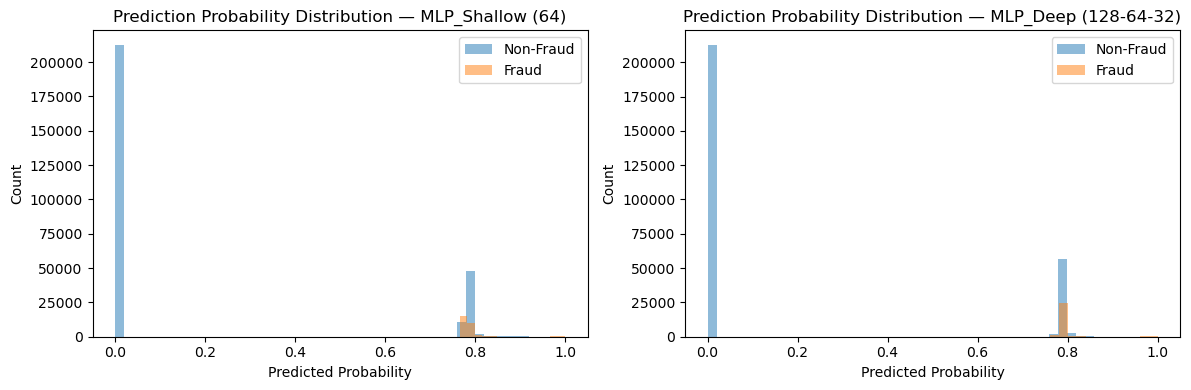

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, y_prob, title in zip(axes, [y_prob_mlp1, y_prob_mlp2], ["MLP_Shallow (64)", "MLP_Deep (128-64-32)"]):
    ax.hist(y_prob[y_test == 0], bins=50, alpha=0.5, label="Non-Fraud")
    ax.hist(y_prob[y_test == 1], bins=50, alpha=0.5, label="Fraud")
    ax.legend()
    ax.set_title(f"Prediction Probability Distribution — {title}")
    ax.set_xlabel("Predicted Probability")
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

In [18]:
# evaluate_thresholds(y_prob_mlp1, y_test)
# evaluate_thresholds(y_prob_mlp2, y_test)

In [19]:
final_evaluation(y_prob_mlp1, y_test, best_threshold_mlp1)


===== FINAL MODEL EVALUATION =====

Best Threshold: 0.7797494118428472

--- Overall Metrics ---
Accuracy    : 0.8135
Precision   : 0.3114
Recall      : 0.8445
Specificity : 0.8104
F1 Score    : 0.4551
MCC         : 0.4375
PR-AUC      : 0.3480

--- Confusion Matrix ---
[[222951  52169]
 [  4343  23595]]

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.98      0.81      0.89    275120
           1       0.31      0.84      0.46     27938

    accuracy                           0.81    303058
   macro avg       0.65      0.83      0.67    303058
weighted avg       0.92      0.81      0.85    303058



In [20]:
final_evaluation(y_prob_mlp2, y_test, best_threshold_mlp2)


===== FINAL MODEL EVALUATION =====

Best Threshold: 0.7845766921796017

--- Overall Metrics ---
Accuracy    : 0.8131
Precision   : 0.3104
Recall      : 0.8416
Specificity : 0.8102
F1 Score    : 0.4536
MCC         : 0.4355
PR-AUC      : 0.3487

--- Confusion Matrix ---
[[222891  52229]
 [  4424  23514]]

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.98      0.81      0.89    275120
           1       0.31      0.84      0.45     27938

    accuracy                           0.81    303058
   macro avg       0.65      0.83      0.67    303058
weighted avg       0.92      0.81      0.85    303058



## Summary Comparison — All Models

In [21]:
summary_rows = []

eval_configs = [
    ("RF_Default",    y_prob1,      best_threshold1),
    ("RF_MaxDepth35", y_prob2,      best_threshold2),
    ("MLP_Shallow",   y_prob_mlp1,  best_threshold_mlp1),
    ("MLP_Deep",      y_prob_mlp2,  best_threshold_mlp2),
]

for name, y_prob, threshold in eval_configs:
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    summary_rows.append({
        "Model":       name,
        "Threshold":   round(threshold, 4),
        "Accuracy":    round(accuracy_score(y_test, y_pred), 4),
        "Precision":   round(precision_score(y_test, y_pred), 4),
        "Recall":      round(recall_score(y_test, y_pred), 4),
        "Specificity": round(specificity, 4),
        "F1":          round(f1_score(y_test, y_pred), 4),
        "MCC":         round(matthews_corrcoef(y_test, y_pred), 4),
        "PR-AUC":      round(average_precision_score(y_test, y_prob), 4),
    })

summary_df = pd.DataFrame(summary_rows).set_index("Model")
summary_df

,Threshold,Accuracy,Precision,Recall,Specificity,F1,MCC,PR-AUC
Model,,,,,,,,
RF_Default,0.4357,0.8129,0.3102,0.8409,0.8101,0.4532,0.4350,0.3459
RF_MaxDepth35,0.6518,0.8129,0.3101,0.8406,0.8101,0.4530,0.4347,0.3428
MLP_Shallow,0.7797,0.8135,0.3114,0.8445,0.8104,0.4551,0.4375,0.3480
MLP_Deep,0.7846,0.8131,0.3104,0.8416,0.8102,0.4536,0.4355,0.3487


## Confusion Matrix

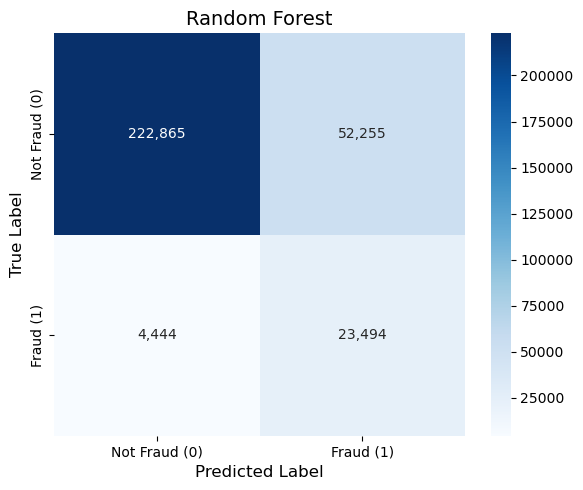

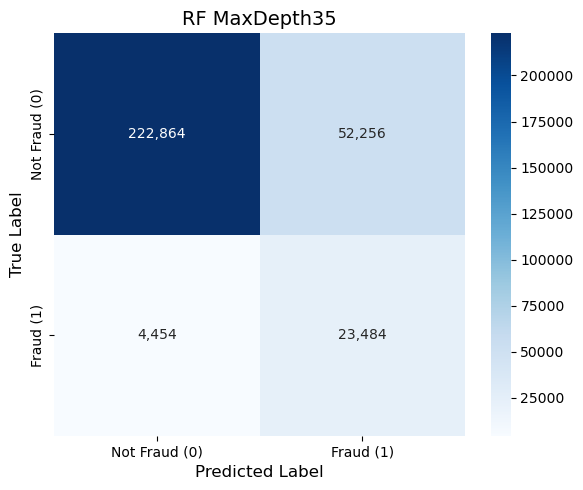

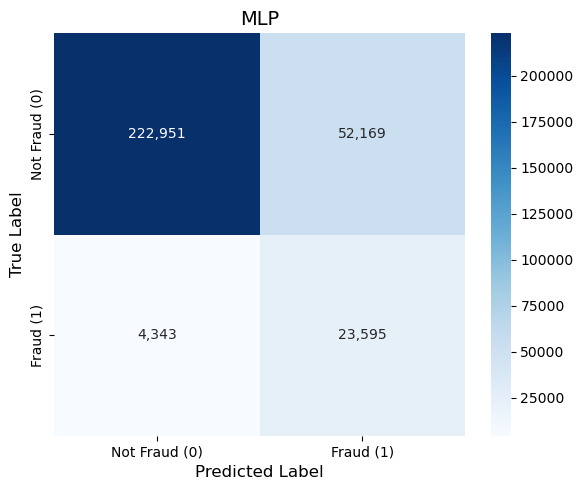

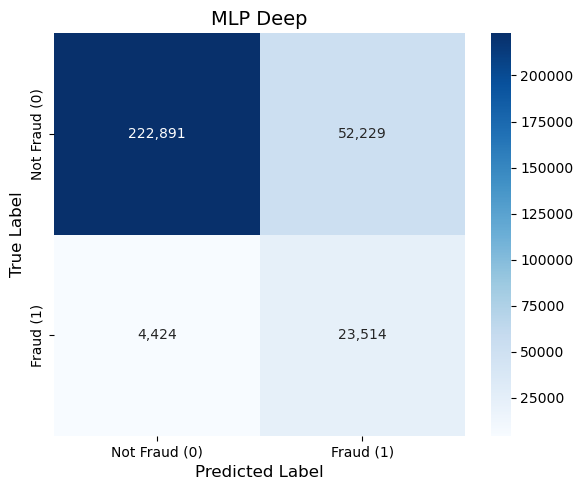

In [23]:
plot_confusion_matrix(y_test, y_prob1,     best_threshold1,     title="Random Forest")
plot_confusion_matrix(y_test, y_prob2,     best_threshold2,     title="RF MaxDepth35")
plot_confusion_matrix(y_test, y_prob_mlp1, best_threshold_mlp1, title="MLP")
plot_confusion_matrix(y_test, y_prob_mlp2, best_threshold_mlp2, title="MLP Deep")